# Stellar Mergers: Metallicity Sweep

In [17]:
import itertools
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import yaml
from IPython.display import display

import time

pd.set_option('display.max_columns', None)

## Helper functions

In [18]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def save_yaml(obj, path):
    with open(path, "w") as f:
        yaml.safe_dump(obj, f, sort_keys=False)

def set_compas_option(cfg, key, value):
    """Insert a key/value into the correct yaml block based on Python type."""
    if isinstance(value, bool):
        cfg.setdefault("booleanChoices", {})[key] = value
    elif isinstance(value, (int, float)):
        cfg.setdefault("numericalChoices", {})[key] = value
    elif isinstance(value, str):
        cfg.setdefault("stringChoices", {})[key] = value
    else:
        raise TypeError(f"unsupported value type for {key}: {type(value)}")

def load_compas_group(h5_path, group_name):
    """Load a COMPAS HDF5 output group into a pandas DataFrame."""
    with h5py.File(h5_path, 'r') as f:
        if group_name not in f:
            return pd.DataFrame()
        group = f[group_name]
        data = {col: group[col][:] for col in group.keys()}
    return pd.DataFrame(data)

## Metallicity × N sweep

Runs 9 simulations: Z ∈ {0.02, 0.002, 0.0002} × N ∈ {1 000, 10 000, 100 000}.
Each run writes its output to an isolated subdirectory so HDF5 files never collide.

In [19]:
BASE_CONFIG = Path("compas_testl_config.yaml")   # reuse your existing base config
RUN_ROOT    = Path("metallicity_sweep")
RUN_ROOT.mkdir(exist_ok=True)

METALLICITIES = [0.02, 0.002, 0.0002]
N_VALUES      = [1_000, 10_000]  # Holding off on 100,000 for now: takes ~5 hours to run

In [20]:
def run_metallicity_case(metallicity, n_systems, seed, base_config=BASE_CONFIG):
    run_name = f"met_{metallicity:.4f}__n_{n_systems}"

    cfg = load_yaml(base_config)
    set_compas_option(cfg, "--metallicity",       float(metallicity))
    set_compas_option(cfg, "--number-of-systems", int(n_systems))
    set_compas_option(cfg, "--random-seed",       int(seed))
    set_compas_option(cfg, "--logfile-type",      "HDF5")
    # don't set --output-path since COMPAS ignores it

    cfg_path = Path(f"config_{run_name}.yaml")
    save_yaml(cfg, cfg_path)

    # snapshot existing COMPAS_Output dirs before running
    before = set(Path(".").glob("COMPAS_Output*"))

    proc = subprocess.run(
        ["compas_run_submit", str(cfg_path)],
        capture_output=True, text=True,
    )
    if proc.returncode != 0:
        print(f"  FAILED [{run_name}]:\n{proc.stderr}")
        return None

    # find whichever new COMPAS_Output dir appeared
    after = set(Path(".").glob("COMPAS_Output*"))
    new_dirs = after - before
    if not new_dirs:
        print(f"  No new COMPAS_Output dir found for {run_name}")
        return None

    new_dir = max(new_dirs, key=lambda p: p.stat().st_mtime)
    h5_files = list(new_dir.glob("**/*.h5"))
    if not h5_files:
        print(f"  No HDF5 found in {new_dir}")
        return None

    h5_path = h5_files[0]
    return h5_path, metallicity, n_systems


def extract_case_counts(h5_path, n_systems):
    """
    Return a dict with per-MT-case CE merger counts and the total N.
    """
    sys_df = load_compas_group(str(h5_path), "BSE_System_Parameters")
    ce_df  = load_compas_group(str(h5_path), "BSE_Common_Envelopes")

    n_total = int(sys_df["SEED"].nunique()) if "SEED" in sys_df.columns else n_systems

    if ce_df.empty or "Merger" not in ce_df.columns:
        return dict(n_total=n_total, case_a=0, case_b=0, case_c=0)

    ce = ce_df.copy()
    donor_type = np.where(
        ce["RLOF(1)"] == 1,
        ce["Stellar_Type(1)<CE"],
        ce["Stellar_Type(2)<CE"],
    )
    merger_mask = ce["Merger"] == 1

    return dict(
        n_total = n_total,
        case_a  = int((donor_type[merger_mask] == 1).sum()),
        case_b  = int((donor_type[merger_mask] == 2).sum()),
        case_c  = int((donor_type[merger_mask]  > 2).sum()),
    )

In [34]:
# ── run the grid ─────────────────────────────────────────────────────────────
rows = []
seed = 200

for metallicity, n in itertools.product(METALLICITIES, N_VALUES):
    start = time.time()

    print(f"Running  Z={metallicity}  N={n:,}  (seed={seed}) ...", end="  ")
    result = run_metallicity_case(metallicity, n, seed=seed)
    seed += 1

    if result is None:
        continue

    h5_path, met, n_sys = result
    counts = extract_case_counts(h5_path, n_sys)

    total = counts["case_a"] + counts["case_b"] + counts["case_c"]
    n_tot = counts["n_total"]

    print(n_tot, metallicity)

    rows.append(dict(
        metallicity = met,
        n_systems   = n_tot,
        case_a      = counts["case_a"],
        case_b      = counts["case_b"],
        case_c      = counts["case_c"],
        total_mergers = total,
        merger_rate = total            / n_tot,
        rate_a      = counts["case_a"] / n_tot,
        rate_b      = counts["case_b"] / n_tot,
        rate_c      = counts["case_c"] / n_tot,
    ))
    print(f"{total} mergers / {n_tot} total (this case ran in {time.time() - start:.2f} seconds)")

results_df = pd.DataFrame(rows)
display(results_df)

Running  Z=0.02  N=1,000  (seed=200) ...  

KeyboardInterrupt: 

## Plot: CE merger rate vs metallicity by MT case

One subplot per N value; within each subplot the x-axis is metallicity and there are three
grouped bars (Case A / B / C) for each Z.

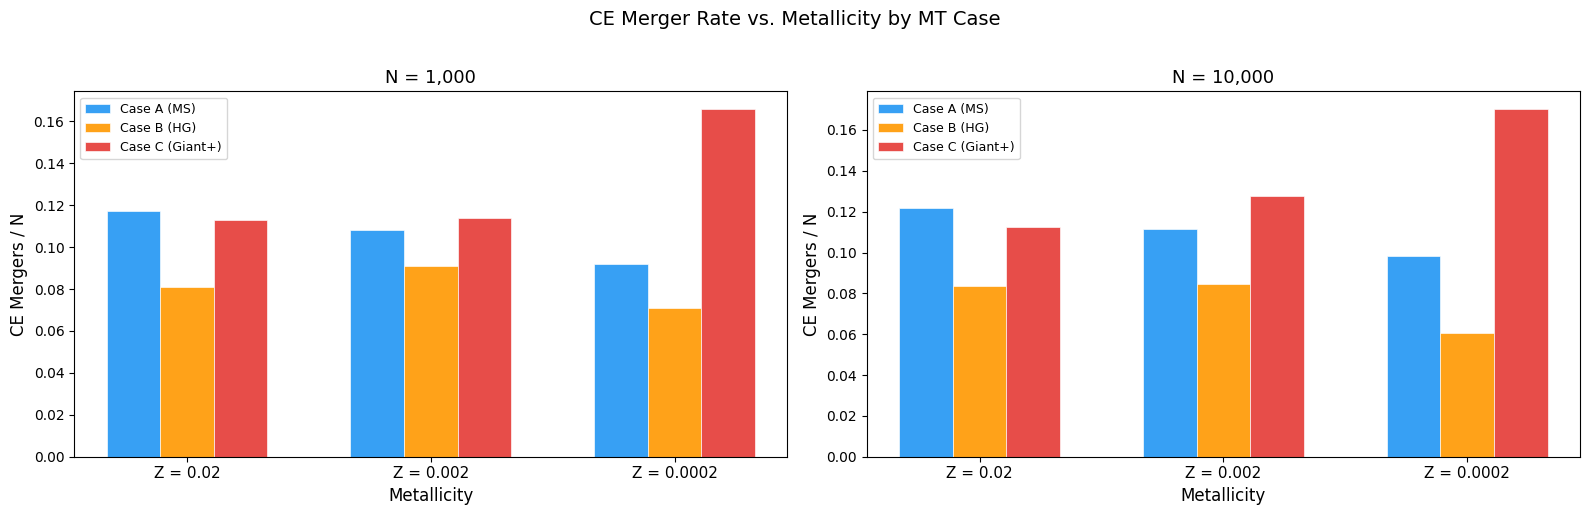

In [ ]:
case_colors = {
    "Case A (MS)":     "#2196F3",
    "Case B (HG)":     "#FF9800",
    "Case C (Giant+)": "#E53935",
}
rate_cols = ["rate_a", "rate_b", "rate_c"]

x      = np.arange(len(METALLICITIES))
width  = 0.22
zlabels = [f"Z = {z}" for z in METALLICITIES]

fig, axes = plt.subplots(1, len(N_VALUES), figsize=(16, 5), sharey=False)

for ax, n in zip(axes, N_VALUES):
    sub = (
        results_df[results_df["n_systems"] == n]
        .set_index("metallicity")
        .reindex(METALLICITIES)   # guarantee the right order even if a run failed
    )

    for j, (label, col) in enumerate(zip(case_colors, rate_cols)):
        offset = (j - 1) * width
        ax.bar(
            x + offset,
            sub[col].values,
            width     = width,
            color     = case_colors[label],
            label     = label,
            edgecolor = "white",
            linewidth = 0.5,
            alpha     = 0.9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(zlabels, fontsize=11)
    ax.set_xlabel("Metallicity", fontsize=12)
    ax.set_ylabel("CE Mergers / N", fontsize=12)
    ax.set_title(f"N = {n:,}", fontsize=13)
    ax.legend(fontsize=9)

fig.suptitle("CE Merger Rate vs. Metallicity by MT Case", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("merger_rate_vs_metallicity.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
def load_compas_group(h5_path, group_name):
    """
    Load a COMPAS HDF5 output group into a dictionary.
    
    Parameters:
    -----------
    h5_path : str
        Path to COMPAS_Output.h5
    group_name : str
        Name of the HDF5 group (e.g., 'BSE_System_Parameters')
    
    Returns:
    --------
    data : dict
        Dictionary mapping column names to numpy arrays
    """
    data = {}
    with h5py.File(h5_path, 'r') as f:
        group = f[group_name]
        for col in group.keys():
            data[col] = group[col][:]
    return data

new_dir = max(set(Path(".").glob("COMPAS_Output*")), key=lambda p: p.stat().st_mtime)
output_path = list(new_dir.glob("**/*.h5"))[0]

sys_params_df = pd.DataFrame(load_compas_group(output_path, 'BSE_System_Parameters'))
sys_params_df.head(10)


ce_df = pd.DataFrame(load_compas_group(output_path, 'BSE_Common_Envelopes'))
ce = ce_df.copy() # copy to avoid modifying original dataframe

# Donor stellar type for CE: take star 1 if RLOF(1)==1, else star 2
donor_type = np.where(
    ce['RLOF(1)'] == 1,
    ce['Stellar_Type(1)<CE'],
    ce['Stellar_Type(2)<CE']
)

ce['donor_type'] = donor_type

# Classify MT case based on donor type
ce['case_A'] = (donor_type == 1)
ce['case_B'] = (donor_type == 2)
ce['case_C'] = (donor_type > 2)

ce_mergers = ce[ce['Merger'] == 1].copy()

# Merge in ZAMS primary mass and binary separation from sys_params_df via SEED
ce_mergers = ce_mergers.merge(
    sys_params_df[['SEED', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'SemiMajorAxis@ZAMS']],
    on='SEED', how='left'
)

ce_mergers.columns

OSError: Unable to synchronously open file (truncated file: eof = 48, sblock->base_addr = 0, stored_eof = 2048)

In [37]:
ce = ce[(ce['Stellar_Type(1)<CE']<10) & (ce['Stellar_Type(2)<CE']<10)] # Remove CE episodes where one component is CO (WD/NS/BH)
ce

,BE_Fixed(1),BE_Fixed(2),BE_Kruckow(1),BE_Kruckow(2),BE_Loveridge(1),BE_Loveridge(2),BE_Loveridge_Winds(1),BE_Loveridge_Winds(2),BE_Nanjing(1),BE_Nanjing(2),Binding_Energy<CE(1),Binding_Energy<CE(2),CE_Event_Counter,Double_Core_CE,Eccentricity<CE,Eccentricity>CE,Immediate_RLOF>CE,Lambda@CE(1),Lambda@CE(2),Lambda_Convective(1),Lambda_Convective(2),Lambda_Fixed(1),Lambda_Fixed(2),Lambda_Kruckow(1),Lambda_Kruckow(2),Lambda_Loveridge(1),Lambda_Loveridge(2),Lambda_Loveridge_Winds(1),Lambda_Loveridge_Winds(2),Lambda_Nanjing(1),Lambda_Nanjing(2),Luminosity<CE(1),Luminosity<CE(2),MT_History,Mass(1)<CE,Mass(1)>CE,Mass(2)<CE,Mass(2)>CE,Mass_Convective_Env(1),Mass_Convective_Env(2),Mass_Env(1),Mass_Env(2),Merger,Optimistic_CE,RLOF(1),RLOF(2),Radius(1)<CE,Radius(1)>CE,Radius(2)<CE,Radius(2)>CE,Record_Type,RocheLobe(1)<CE,RocheLobe(1)>CE,RocheLobe(2)<CE,RocheLobe(2)>CE,SEED,SemiMajorAxis<CE,SemiMajorAxis>CE,SemiMajorAxisStage1>CE,Simultaneous_RLOF,Stellar_Type(1),Stellar_Type(1)<CE,Stellar_Type(2),Stellar_Type(2)<CE,Tau_Circ,Tau_Dynamical<CE(1),Tau_Dynamical<CE(2),Tau_Radial<CE(1),Tau_Radial<CE(2),Tau_Sync(1),Tau_Sync(2),Tau_Thermal<CE(1),Tau_Thermal<CE(2),Teff<CE(1),Teff<CE(2),Time,Zeta_Lobe,Zeta_Star,donor_type,case_A,case_B,case_C
0,0.000000e+00,1.558755e+49,0.000000e+00,3.972445e+46,0.000000e+00,1.558755e+48,0.000000e+00,1.558755e+48,0.000000e+00,1.558755e+48,1.298033e+47,1.558755e+48,1,0,0.0,0.0,0,2.164570,1.0,0.924362,1.215653,0.1,0.1,0.451222,39.239172,1.0,1.0,1.0,1.0,2.164570,1.0,22562.406215,0.029080,6,5.373059,0.000000,0.365624,0.000000,0.0,0.337908,3.636829,0.0,1,0,1,0,263.939961,0.000000,0.325469,0.000000,1,260.419858,0.00000,79.124670,0.000000,42,428.566113,0.000000,0.0,0,5,5,0,0,0.0,9.249472e-08,1.535387e-11,0.231929,1.046892e+06,0.0,0.0,0.000103,443.498679,4358.843906,4182.361737,84.368968,26.576573,0.177194,5,False,False,True
1,4.819119e+50,4.819119e+50,3.466745e+48,3.466745e+48,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,1,0,0.0,0.0,0,1.000000,1.0,0.961403,0.961403,0.1,0.1,13.900989,13.900989,1.0,1.0,1.0,1.0,1.000000,1.0,457.577298,457.577298,6,4.427263,0.000000,4.427263,0.000000,0.0,0.000000,0.000000,0.0,1,0,1,1,1.543553,0.000000,1.543553,0.000000,1,1.368724,0.00000,1.368724,0.000000,43,3.612166,0.000000,0.0,1,1,1,1,1,0.0,4.557057e-11,4.557057e-11,-1.000000,-1.000000e+00,0.0,0.0,0.871394,0.871394,21509.629951,21509.629951,0.000000,0.000000,0.000000,1,True,False,False
2,1.721885e+51,2.899345e+49,2.218906e+49,1.116837e+47,1.721885e+50,2.899345e+48,1.721885e+50,2.899345e+48,1.721885e+50,2.899345e+48,1.721885e+50,2.899345e+48,1,0,0.0,0.0,0,1.000000,1.0,1.088921,1.221268,0.1,0.1,7.760062,25.960332,1.0,1.0,1.0,1.0,1.000000,1.0,18300.554110,0.259423,6,12.958030,0.000000,0.679756,0.000000,0.0,0.140497,0.000000,0.0,1,0,1,0,3.700771,0.000000,0.604818,0.000000,1,3.691756,0.00000,1.006548,0.000000,46,5.893639,0.000000,0.0,0,1,1,0,0,0.0,9.888692e-11,2.852531e-11,26.109305,1.856284e+05,0.0,0.0,0.077849,92.470448,34933.933356,5302.336297,8.412412,35.288612,2.000000,1,True,False,False
3,-1.025312e+34,3.058216e+51,-1.076965e+33,5.773602e+49,-1.025312e+33,3.058216e+50,-1.025312e+33,3.058216e+50,-2.763577e+33,3.058216e+50,9.061364e+49,3.058216e+50,1,0,0.0,0.0,0,0.371009,1.0,1.091154,1.260796,0.1,0.1,0.952039,5.296894,1.0,1.0,1.0,1.0,0.371009,1.0,534353.765425,106487.137385,6,34.935629,0.000000,22.996087,0.000000,0.0,0.000000,21.837311,0.0,1,0,1,0,86.120801,0.000000,6.562331,0.000000,1,85.961907,0.00000,71.021670,0.000000,47,206.849006,0.000000,0.0,0,4,4,1,1,0.0,6.760796e-09,1.752791e-10,0.145303,6.876047e+00,0.0,0.0,0.000521,0.023762,16833.744272,40744.854556,6.046913,0.862137,0.273777,4,False,False,True
5,5.089784e+51,1.441627e+51,1.343258e+50,1.516744e+49,5.089784e+50,1.441627e+50,5.089784e+50,1.441627e+50,5.089784e+50,1.441627e+50,5.089784e+50,1.441627e+50,1,0,0.0,0.0,0,1.000000,1.0,1.572778,1.045696,0.1,0.1,3.789135,9.504751,1.0,1.0,1.0,1.0,1.000000,1.0,374920.872259,6996.00405

## Verify alpha_CE independence

In [ ]:
# ── alpha_CE sweep (verify CE count independence) ────────────────────────────
ALPHA_VALUES  = [0.5, 1.0, 2.0]
METALLICITIES_ALPHA = [0.02, 0.002, 0.0002]
N_ALPHA       = 1_000   # match your existing runs

alpha_rows = []
seed = 300

for alpha, metallicity in itertools.product(ALPHA_VALUES, METALLICITIES_ALPHA):
    run_name = f"alpha_{alpha}__met_{metallicity:.4f}"
    cfg = load_yaml(BASE_CONFIG)
    set_compas_option(cfg, "--metallicity",          float(metallicity))
    set_compas_option(cfg, "--number-of-systems",    int(N_ALPHA))
    set_compas_option(cfg, "--random-seed",          int(seed))
    set_compas_option(cfg, "--common-envelope-alpha", float(alpha))
    set_compas_option(cfg, "--logfile-type",         "HDF5")

    cfg_path = Path(f"config_{run_name}.yaml")
    save_yaml(cfg, cfg_path)

    before = set(Path(".").glob("COMPAS_Output*"))
    proc = subprocess.run(["compas_run_submit", str(cfg_path)], capture_output=True, text=True)
    seed += 1

    if proc.returncode != 0:
        print(f"  FAILED [{run_name}]")
        continue

    after   = set(Path(".").glob("COMPAS_Output*"))
    new_dir = max(after - before, key=lambda p: p.stat().st_mtime, default=None)
    if new_dir is None:
        print(f"  No output dir for {run_name}")
        continue

    h5_files = list(new_dir.glob("**/*.h5"))
    if not h5_files:
        print(f"  No HDF5 for {run_name}")
        continue

    ce_df  = load_compas_group(str(h5_files[0]), "BSE_Common_Envelopes")
    sys_df = load_compas_group(str(h5_files[0]), "BSE_System_Parameters")

    n_ce_events  = len(ce_df)
    n_ce_systems = ce_df["SEED"].nunique() if not ce_df.empty else 0
    n_total      = sys_df["SEED"].nunique() if not sys_df.empty else N_ALPHA

    alpha_rows.append(dict(
        alpha       = alpha,
        metallicity = metallicity,
        n_total     = n_total,
        n_ce_events = n_ce_events,
        n_ce_systems= n_ce_systems,
        ce_rate     = n_ce_systems / n_total,
    ))
    print(f"  alpha={alpha}  Z={metallicity}  → {n_ce_systems} CE systems / {n_total} total")

alpha_df = pd.DataFrame(alpha_rows)
display(alpha_df.pivot(index="metallicity", columns="alpha", values="n_ce_systems"))

  alpha=0.5  Z=0.02  → 441 CE systems / 1000 total
  alpha=0.5  Z=0.002  → 461 CE systems / 1000 total
  alpha=0.5  Z=0.0002  → 427 CE systems / 1000 total
  alpha=1.0  Z=0.02  → 440 CE systems / 1000 total
  alpha=1.0  Z=0.002  → 461 CE systems / 1000 total
  alpha=1.0  Z=0.0002  → 427 CE systems / 1000 total
  alpha=2.0  Z=0.02  → 440 CE systems / 1000 total
  alpha=2.0  Z=0.002  → 462 CE systems / 1000 total
  alpha=2.0  Z=0.0002  → 428 CE systems / 1000 total


alpha,0.5,1.0,2.0
metallicity,,,
0.0002,427,427,428
0.0020,461,461,462
0.0200,441,440,440


From the table above, it's clear that the CE system counts are identical (within random seed noise) between alpha=0.5, 1.0, and 2.0 for all three metallicities. This confirms that alpha_CE only affects the outcome of the CE (whether the system survives or merges, and the post-CE separation), not whether a CE is triggered in the first place.

In [23]:
! compas_run_submit compas_testl_config.yaml

python_version = 3
compas_executable_override /Users/tsdevictor/Software/COMPAS/src/COMPAS
grid_filename None
/Users/tsdevictor/Software/COMPAS/src/COMPAS --detailed-output False --number-of-systems 1000 --metallicity 0.0001 --random-seed 42 --mass-transfer-fa 0.5 --common-envelope-alpha 1.0 --mode BSE --logfile-type HDF5 --output-path /Users/tsdevictor/Documents/menon-lab/stellar_mergers/tutorial/week-2

COMPAS v03.29.03 (gsl v2.8, boost v1.90.0, HDF5 v2.1.1)
Compact Object Mergers: Population Astrophysics and Statistics
by Team COMPAS (http://compas.science/index.html)
A binary star simulator

Go to https://compas.readthedocs.io/en/latest/index.html for the online documentation
Check https://compas.readthedocs.io/en/latest/pages/whats-new.html to see what's new in the latest release

Start generating binaries at Wed Apr 15 17:21:58 2026

0: Stars merged: (Main_Sequence_>_0.7 -> Early_Asymptotic_Giant_Branch) + (Main_Sequence_<=_0.7 -> Main_Sequence_<=_0.7)
1: Stars merged: (Main_Sequ

In [25]:
with h5py.File(H5_PATH, "r") as f:
    for group_name in f.keys():
        print(f"{'─'*60}")
        print(f"GROUP: {group_name}")
        print(f"{'─'*60}")
        group = f[group_name]
        for col in sorted(group.keys()):
            data = group[col][:]
            if data.dtype.kind == 'S':  # byte string columns
                uniq = [v.decode() for v in np.unique(data)[:10]]
                print(f"  {col:<45} unique values: {uniq}")
            elif data.dtype.kind in ('i', 'u', 'b') and len(np.unique(data)) <= 10:
                print(f"  {col:<45} unique values: {sorted(np.unique(data).tolist())}")
            else:
                print(f"  {col:<45} dtype={data.dtype}  range=[{data.min():.3g}, {data.max():.3g}]")
        print()

────────────────────────────────────────────────────────────
GROUP: BSE_Common_Envelopes
────────────────────────────────────────────────────────────
  BE_Fixed(1)                                   dtype=float64  range=[-2.93e+33, 1.69e+52]
  BE_Fixed(2)                                   dtype=float64  range=[-1.31e+33, 1.69e+52]
  BE_Kruckow(1)                                 dtype=float64  range=[-1.67e+32, 5.65e+50]
  BE_Kruckow(2)                                 dtype=float64  range=[-1.35e+32, 5.65e+50]
  BE_Loveridge(1)                               dtype=float64  range=[-2.93e+32, 1.69e+51]
  BE_Loveridge(2)                               dtype=float64  range=[-1.31e+32, 1.69e+51]
  BE_Loveridge_Winds(1)                         dtype=float64  range=[-2.93e+32, 1.69e+51]
  BE_Loveridge_Winds(2)                         dtype=float64  range=[-1.31e+32, 1.69e+51]
  BE_Nanjing(1)                                 dtype=float64  range=[-4.19e+32, 2.33e+51]
  BE_Nanjing(2)                

COMPAS records stellar mergers through several distinct output columns across its HDF5 log groups, each corresponding to a different physical mechanism.
The most general merger flag is Merger in BSE_System_Parameters, which is set to 1 for any binary that merged regardless of cause. The Evolution_Status column in the same group provides additional context — a value of 3 indicates the system terminated because the stars came into contact (separation ≤ r1 + r2), representing direct stellar coalescence without a common envelope phase.
Mass transfer instability (q < q_crit) is captured in BSE_RLOF through the MassTransferTimescale column, which takes integer values 0–3 where 3 denotes dynamical timescale mass transfer — the signature of an unstable, runaway episode. The MassTransferRateDonor column in the same group provides a continuous measure of this: values approaching the float maximum (~1.8×10³⁰⁸) indicate a numerically divergent, physically runaway transfer rate. The Merger flag within BSE_RLOF then records whether that unstable episode terminated in a merger directly.
For the common envelope channel, the relevant flag is Merger in BSE_Common_Envelopes, which is set to 1 when the alpha_CE energy formalism determines that the available orbital energy is insufficient to eject the envelope — causing the companion to spiral all the way in. The Optimistic_CE flag in the same group additionally marks cases where COMPAS proceeded with a CE that would otherwise be classified as a certain merger, providing a way to separate pessimistic from optimistic CE outcomes.
Together these columns allow every merger in the simulation to be classified by its physical origin: direct contact, dynamically unstable mass transfer, or common envelope inspiral.

Determine the differences in finding q_crit across different papers and find what the default is for COMPAS

critical-mass-ratio-prescription    'NONE'    DEFAULT_USED

So by default COMPAS doesn't use a single q_crit prescription at all — instead it uses fixed per-stellar-type critical mass ratios, which are also visible in your output:

critical-mass-ratio-MS-high-mass-non-degenerate-accretor    0.625
critical-mass-ratio-HG-non-degenerate-accretor              0.25
critical-mass-ratio-giant-non-degenerate-accretor          -1.0      (always stable)
critical-mass-ratio-white-dwarf-non-degenerate-accretor     0.0
...etc

The main papers are:

Hjellming & Webbink (1987) — the classical analytic derivation for adiabatic mass transfer, q_crit depends on the donor's adiabatic mass-radius exponent ζ. This is the foundation most later work builds on.
Claeys et al. (2014) — parametrized q_crit values per stellar type, widely used in population synthesis. This is one of the named prescriptions in COMPAS (CLAEYS).
Ge et al. (2010, 2015, 2020) — more detailed calculations of ζ for evolved donors, leading to higher q_crit values than Hjellming & Webbink for giant donors. Also a named COMPAS option (GE).
Woods & Ivanova (2011) / Pavlovskii & Ivanova (2015) — showed that for HG donors q_crit is significantly higher than previously thought because the thermal response of the donor matters.
The core disagreement across papers is whether mass transfer stability is determined by the adiabatic response of the donor (Hjellming & Webbink — more pessimistic, more CE) or the thermal response (Ge, Pavlovskii — more optimistic, more stable MT), which leads to order-of-magnitude differences in predicted merger and DCO rates. 